# Reproducing *"Tensor networks for hierarchical lattices"* — the Ising model (Fig. 3)

This notebook reproduces Fig. 3 of

> S. S. Akimenko and A. V. Myshlyavtsev, *"Tensor networks for hierarchical lattices"*, **EPL** 148, 61001 (2024). [doi:10.1209/0295-5075/ad994b](https://doi.org/10.1209/0295-5075/ad994b)

using the `htn` codebase. The heavy lifting lives in `reproduce/_common.py`, which is shared with the standalone script `reproduce/figure3_ising.py`, so the notebook and the script compute identical numbers.

**Requirements:** `pip install -r requirements-plot.txt` (NumPy + Matplotlib).

In [1]:
import os, sys

# Make the repository root importable regardless of the working directory
# (walk up until we find the folder that holds reproduce/ and htn/).
ROOT = os.getcwd()
while ROOT != os.path.dirname(ROOT):
    if all(os.path.isdir(os.path.join(ROOT, d)) for d in ("reproduce", "htn")):
        break
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
from reproduce import _common as C

plt = C.setup_style()
%matplotlib inline

## Fig. 3(a) — Ising model on the diamond hierarchical lattice (DHL)

At zero field we run the HTN iteration for a *fixed* number of steps `k` (instead of to convergence). As `k` grows, the heat-capacity peak marches towards the exact DHL critical temperature $k_B T_c / J = 1.641$.

k =  1:  T_peak = 1.255
k =  2:  T_peak = 1.450
k =  4:  T_peak = 1.585
k =  6:  T_peak = 1.625
k = 12:  T_peak = 1.640


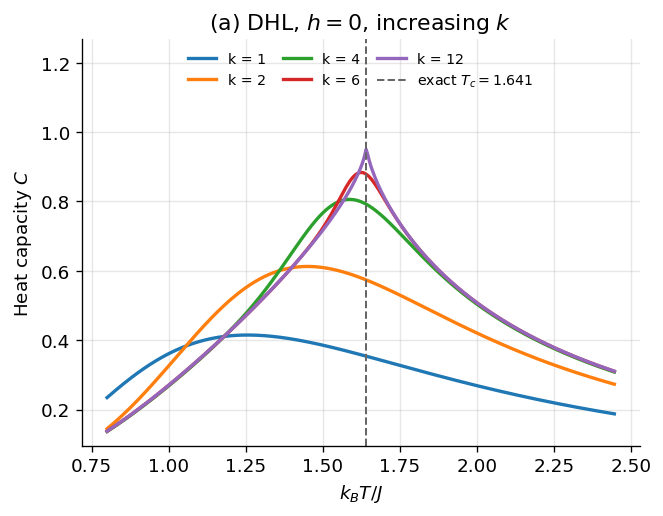

In [2]:
Ta = np.arange(0.80, 2.45, 0.005)
fig, ax = plt.subplots(figsize=(6, 4.4))
for k in (1, 2, 4, 6, 12):
    cv = C.ising_cv_curve_fixed_k("diamond", Ta, k=k, h=0.0, J=1.0, coord=3)
    ax.plot(Ta, cv, label=f"k = {k}")
    print(f"k = {k:>2}:  T_peak = {C.peak(Ta, cv)[0]:.3f}")
ax.axvline(C.TC_DHL, color="0.4", ls="--", lw=1.2, label=r"exact $T_c = 1.641$")
ax.set_xlabel(r"$k_B T / J$"); ax.set_ylabel("Heat capacity $C$")
ax.set_title("(a) DHL, $h = 0$, increasing $k$")
ax.set_ylim(top=ax.get_ylim()[1] * 1.28)
ax.legend(loc="upper center", ncol=3, fontsize=8.5, columnspacing=1.2)
plt.show()

## Fig. 3(b) — the FSHL family at zero field

For every member $p$ of the folded-square hierarchical-lattice family the peak sits at the exact square-lattice value $k_B T_c / J = 2/\ln(1+\sqrt{2}) = 2.269$; larger $p$ only raises the peak height.

p =  1:  T_peak = 2.270
p =  2:  T_peak = 2.270
p =  5:  T_peak = 2.270
p = 10:  T_peak = 2.270


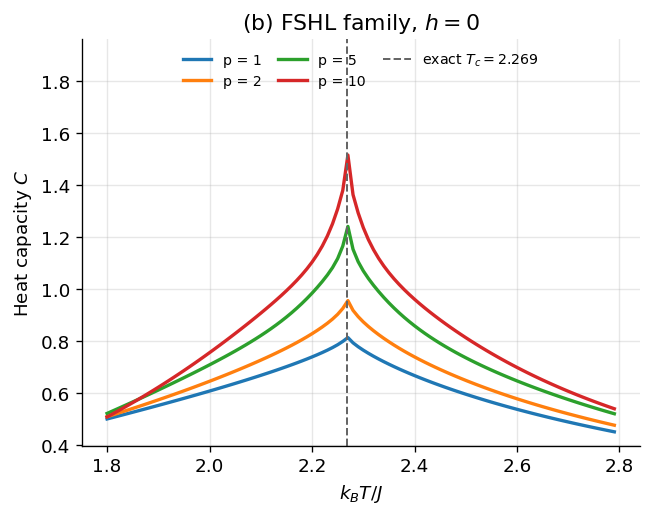

In [3]:
Tb = np.arange(1.80, 2.80, 0.01)
fig, ax = plt.subplots(figsize=(6, 4.4))
for p in (1, 2, 5, 10):
    cv = C.ising_cv_curve("FSHL", Tb, h=0.0, J=1.0, metParam=p)
    ax.plot(Tb, cv, label=f"p = {p}")
    print(f"p = {p:>2}:  T_peak = {C.peak(Tb, cv)[0]:.3f}")
ax.axvline(C.TC_SQUARE, color="0.4", ls="--", lw=1.2, label=r"exact $T_c = 2.269$")
ax.set_xlabel(r"$k_B T / J$"); ax.set_ylabel("Heat capacity $C$")
ax.set_title("(b) FSHL family, $h = 0$")
ax.set_ylim(top=ax.get_ylim()[1] * 1.25)
ax.legend(loc="upper center", ncol=3, fontsize=8.5, columnspacing=1.2)
plt.show()

## Fig. 3(c) — antiferromagnet in a field

With the single-node field set to $\beta h = 1$ and $J < 0$, the critical point shifts as the FSHL member $p$ grows closer to the square lattice. The peaks sharpen with $p$ (the $p = 10$ peak has a half-width of only ~0.13), so a narrow window and a fine temperature step are used here.

1
2
5
10


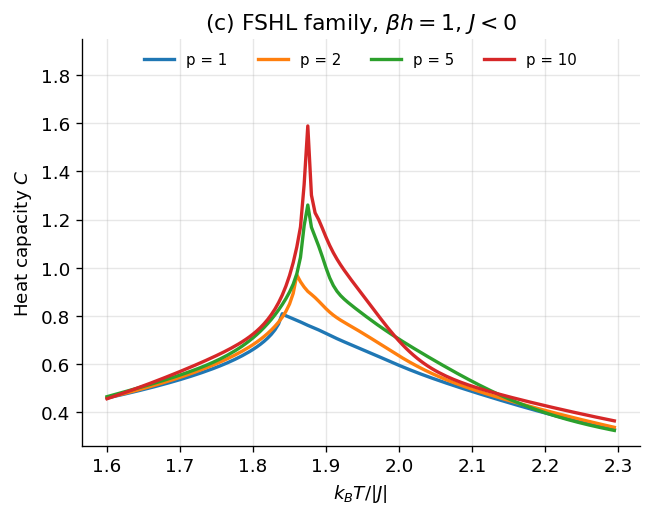

In [5]:
Tc = np.arange(1.60, 2.30, 0.005)
fig, ax = plt.subplots(figsize=(6, 4.4))
for p in (1, 2, 5, 10):
    print(p)
    cv = C.ising_cv_curve("FSHL", Tc, betah=1.0, J=-1.0, metParam=p)
    ax.plot(Tc, cv, label=f"p = {p}")
ax.set_xlabel(r"$k_B T / |J|$"); ax.set_ylabel("Heat capacity $C$")
ax.set_title(r"(c) FSHL family, $\beta h = 1$, $J < 0$")
ax.set_ylim(top=ax.get_ylim()[1] * 1.18)
ax.legend(loc="upper center", ncol=4, fontsize=9)
plt.show()

## Takeaways

* The HTN iteration reproduces the **exact** critical temperatures of the diamond ($1.641$) and square ($2.269$) lattices.
* The single-node-interaction trick lets a hierarchical lattice mimic a regular (square) lattice, including in an external field.
* Because each contraction step is cheap, full heat-capacity scans are obtained in seconds.